In [19]:
import numpy as np
import pandas as pd

DATA_PATH = "/lustre09/project/6081099/reem2005/DATASET/UCI HAR Dataset/"

# ==========================
# Load Training Signals
# ==========================

signals = [
    "body_acc_x",
    "body_acc_y",
    "body_acc_z",
    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",
    "total_acc_x",
    "total_acc_y",
    "total_acc_z"
]

X_train = np.stack([
    pd.read_csv(
        DATA_PATH + f"train/Inertial Signals/{signal}_train.txt",
        sep=r"\s+",
        header=None
    ).values
    for signal in signals
], axis=2)

X_test = np.stack([
    pd.read_csv(
        DATA_PATH + f"test/Inertial Signals/{signal}_test.txt",
        sep=r"\s+",
        header=None
    ).values
    for signal in signals
], axis=2)

y_train = (
    pd.read_csv(
        DATA_PATH + "train/y_train.txt",
        header=None
    ).values.flatten() - 1
)

y_test = (
    pd.read_csv(
        DATA_PATH + "test/y_test.txt",
        header=None
    ).values.flatten() - 1
)

activity_labels = pd.read_csv(
    DATA_PATH + "activity_labels.txt",
    sep=r"\s+",
    header=None
)

LABELS = activity_labels[1].tolist()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)
print("Activities:", LABELS)

X_train: (7352, 128, 9)
X_test : (2947, 128, 9)
y_train: (7352,)
y_test : (2947,)
Activities: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']


# UCI HAR - Deep Learning Models

This notebook trains and compares multiple deep learning architectures on the UCI Human Activity Recognition dataset.

Models evaluated:
- CNN
- RNN
- LSTM
- DeepConvLSTM

Evaluation Metrics:
- Accuracy
- Precision
- Recall
- Macro F1-score

In [3]:
import os
os.environ.pop("PIP_PREFIX", None)

import sys

!{sys.executable} -m pip install --no-index --user --ignore-installed tensorflow

Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v4, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
Processing /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic/tensorflow-2.19.1+computecanada-cp311-cp311-linux_x86_64.whl
Processing /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic/absl_py-2.5.0+computecanada-py3-none-any.whl (from tensorflow)
Processing /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic/astunparse-1.6.3+computecanada-py2.py3-none-any.whl (from tensorflow)
Processing /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic/flatbuffers-25.12.19+computecanada-py2.py3-none-any.whl (from tensorflow)
Processing /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic/gast-0.7.0+computecanada-py3-none-any.whl (from te

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    Flatten,
    LSTM,
    GlobalMaxPooling1D,
    Reshape
)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

## Prepare Input

Different deep learning architectures require different input shapes.

In [22]:
def prepare_input(X, model_name):

    if model_name.lower() in ["cnn", "deepconvlstm"]:
        return X[..., np.newaxis]

    return X

In [24]:
print(prepare_input(X_train, "cnn").shape)

(7352, 128, 9, 1)


# Convolutional Neural Network (CNN)

The CNN model learns spatial patterns from multichannel inertial sensor signals using convolutional layers. Batch normalization and dropout are used to improve generalization and reduce overfitting.

In [25]:
print("CNN Input Shape:", prepare_input(X_train, "cnn").shape)
print("LSTM Input Shape:", prepare_input(X_train, "lstm").shape)

CNN Input Shape: (7352, 128, 9, 1)
LSTM Input Shape: (7352, 128, 9)


In [26]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers


def build_cnn(input_shape, n_classes):

    inputs = Input(shape=input_shape)

    # Block 1
    x = Conv2D(
        filters=64,
        kernel_size=(3,3),
        padding="same",
        activation="relu",
        kernel_regularizer=regularizers.l2(0.0005)
    )(inputs)

    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2,1))(x)
    x = Dropout(0.3)(x)

    # Block 2
    x = Conv2D(
        filters=64,
        kernel_size=(3,3),
        padding="same",
        activation="relu",
        kernel_regularizer=regularizers.l2(0.0005)
    )(x)

    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2,1))(x)
    x = Dropout(0.3)(x)

    # Classification Head
    x = Flatten()(x)

    x = Dense(
        128,
        activation="relu"
    )(x)

    x = Dropout(0.5)(x)

    outputs = Dense(
        n_classes,
        activation="softmax"
    )(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [27]:
cnn = build_cnn(
    prepare_input(X_train, "cnn").shape[1:],
    len(np.unique(y_train))
)

cnn.summary()

I0000 00:00:1784053520.890419 3394295 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 78750 MB memory:  -> device: 0, name: NVIDIA H100 80GB HBM3, pci bus id: 0000:db:00.0, compute capability: 9.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 9, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 9, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 9, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 9, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 9, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 9, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 9, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 9, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 9, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,398,278 (9.15 MB)

 Trainable params: 2,398,022 (9.15 MB)

 Non-trainable params: 256 (1.00 KB)

# Recurrent Neural Network (RNN)

The RNN model captures temporal dependencies between consecutive sensor readings using recurrent connections.

In [29]:
from tensorflow.keras.layers import (
    Input,
    SimpleRNN,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers


def build_rnn(input_shape, n_classes):

    inputs = Input(shape=input_shape)

    x = SimpleRNN(
        units=128,
        return_sequences=False,
        dropout=0.3,
        recurrent_dropout=0.3,
        kernel_regularizer=regularizers.l2(0.0005)
    )(inputs)

    x = BatchNormalization()(x)

    x = Dense(
        64,
        activation="relu"
    )(x)

    x = Dropout(0.5)(x)

    outputs = Dense(
        n_classes,
        activation="softmax"
    )(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Long Short-Term Memory (LSTM)

LSTM networks overcome the short-memory limitation of traditional RNNs by using memory cells and gating mechanisms. They are widely used for Human Activity Recognition because they effectively model long temporal dependencies.

In [30]:
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers


def build_lstm(input_shape, n_classes):

    inputs = Input(shape=input_shape)

    # LSTM Layer
    x = LSTM(
        units=128,
        return_sequences=False,
        dropout=0.3,
        recurrent_dropout=0.3,
        kernel_regularizer=regularizers.l2(1e-4)
    )(inputs)

    x = BatchNormalization()(x)

    # Fully Connected Layer
    x = Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)

    x = Dropout(0.5)(x)

    outputs = Dense(
        n_classes,
        activation="softmax"
    )(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(
            learning_rate=1e-3
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# DeepConvLSTM

DeepConvLSTM combines convolutional layers for spatial feature extraction with Long Short-Term Memory (LSTM) layers for temporal modeling. This architecture is considered one of the strongest deep learning models for Human Activity Recognition because it captures both local sensor patterns and long-term temporal dependencies.

In [31]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    Reshape,
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers


def build_deepconv_lstm(input_shape, n_classes):

    inputs = Input(shape=input_shape)

    # Convolution Block 1
    x = Conv2D(
        filters=64,
        kernel_size=(5,1),
        padding="same",
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    )(inputs)

    x = BatchNormalization()(x)

    # Convolution Block 2
    x = Conv2D(
        filters=64,
        kernel_size=(5,1),
        padding="same",
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)

    x = BatchNormalization()(x)

    x = MaxPooling2D(pool_size=(2,1))(x)

    # Convert CNN output to sequence
    x = Reshape((-1, x.shape[2] * x.shape[3]))(x)

    # LSTM
    x = LSTM(
        units=128,
        dropout=0.3,
        recurrent_dropout=0.3,
        return_sequences=False
    )(x)

    # Classification
    x = Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)

    x = Dropout(0.5)(x)

    outputs = Dense(
        n_classes,
        activation="softmax"
    )(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Model Dictionary

All deep learning models are stored in a dictionary to allow automatic training and evaluation using a single loop.

In [32]:
MODELS = {
    "CNN": build_cnn,
    "RNN": build_rnn,
    "LSTM": build_lstm,
    "DeepConvLSTM": build_deepconv_lstm
}

NUM_CLASSES = len(np.unique(y_train))

print(MODELS.keys())
print("Number of classes:", NUM_CLASSES)

dict_keys(['CNN', 'RNN', 'LSTM', 'DeepConvLSTM'])
Number of classes: 6


# Training and Evaluation

Each deep learning model is trained using the same training and testing sets. Early stopping is applied to reduce overfitting, and the models are compared using Accuracy, Precision, Recall, and Macro F1-score.

In [34]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

In [36]:
histories = {}
trained_models = {}

best_f1 = 0
best_model_name = None
best_predictions = None

for model_name, builder in MODELS.items():

    print("=" * 60)
    print(f"Training {model_name}")
    print("=" * 60)

    X_train_model = prepare_input(X_train, model_name)
    X_test_model = prepare_input(X_test, model_name)

    model = builder(
        X_train_model.shape[1:],
        NUM_CLASSES
    )

    history = model.fit(
        X_train_model,
        y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=64,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    histories[model_name] = history
    trained_models[model_name] = model

    y_prob = model.predict(X_test_model, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test, y_pred,
        average="macro",
        zero_division=0
    )
    recall = recall_score(
        y_test, y_pred,
        average="macro",
        zero_division=0
    )
    macro_f1 = f1_score(
        y_test, y_pred,
        average="macro"
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Macro F1": macro_f1
    })

    if macro_f1 > best_f1:
        best_f1 = macro_f1
        best_model_name = model_name
        best_predictions = y_pred

Training CNN
Epoch 1/50


I0000 00:00:1784054237.750262 3457762 service.cc:152] XLA service 0x14992c015620 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784054237.750569 3457762 service.cc:160]   StreamExecutor device (0): NVIDIA H100 80GB HBM3, Compute Capability 9.0
2026-07-14 14:37:17.910646: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784054238.263080 3457762 cuda_dnn.cc:529] Loaded cuDNN version 91000
2026-07-14 14:37:19.351556: W external/local_xla/xla/stream_executor/gpu/redzone_allocator_kernel_cuda.cc:135] NOT_FOUND: Couldn't find a suitable version of ptxas. The following locations were considered: bin/ptxas, /cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v4/Compiler/gcccore/ipython-kernel/3.11/bin/ptxas, /cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v4/Compiler/gcccore/python/3.11.5/bin/ptxas, /c

31/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5248 - loss: 3.5001  

I0000 00:00:1784054244.986114 3457762 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.6744 - loss: 1.2040 - val_accuracy: 0.1992 - val_loss: 14.1225 - learning_rate: 0.0010
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7710 - loss: 0.5900 - val_accuracy: 0.3698 - val_loss: 19.8276 - learning_rate: 0.0010
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8397 - loss: 0.4225 - val_accuracy: 0.4983 - val_loss: 17.9767 - learning_rate: 0.0010
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8680 - loss: 0.3531 - val_accuracy: 0.4840 - val_loss: 8.2311 - learning_rate: 0.0010
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8856 - loss: 0.3077 - val_accuracy: 0.5126 - val_loss: 5.3092 - learning_rate: 0.0010
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9078 - loss: 0.2575 - val_accuracy: 0.7396 - val_loss: 1.6165 - learning_rate: 0.0010
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9252 - loss: 0.2123 - val_accuracy: 0.8885

2026-07-14 14:37:34.773769: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_77', 4 bytes spill stores, 4 bytes spill loads



Training RNN
Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.2673 - loss: 2.0097 - val_accuracy: 0.3630 - val_loss: 1.4819 - learning_rate: 0.0010
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2971 - loss: 1.7185 - val_accuracy: 0.3215 - val_loss: 1.4289 - learning_rate: 0.0010
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3166 - loss: 1.6122 - val_accuracy: 0.3209 - val_loss: 1.4122 - learning_rate: 0.0010
Epoch 4/50
86/92 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3382 - loss: 1.5584
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3436 - loss: 1.5522 - val_accuracy: 0.4840 - val_loss: 1.3676 - learning_rate: 0.0010
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3515 - loss: 1.5234 - val_accuracy: 0.4616 - val_loss: 1.3370 - learning_rate: 5.0000e-04
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3413 - loss: 1.5303

# Performance Comparison

The following table summarizes the performance of all evaluated deep learning models.

In [37]:
# ==========================================
# Model Performance Comparison
# ==========================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,Macro F1
0,LSTM,0.911775,0.917626,0.912513,0.911660
1,DeepConvLSTM,0.907363,0.910901,0.910795,0.908859
2,CNN,0.885986,0.893791,0.883482,0.885025
3,RNN,0.379708,0.476169,0.362197,0.354108


In [38]:
# ==========================================
# Styled Results Table
# ==========================================

results_df.style\
    .background_gradient(cmap="Greens")\
    .format("{:.4f}")

ValueError: Unknown format code 'f' for object of type 'str'

In [45]:
results_df

,Model,Accuracy,Precision,Recall,Macro F1
0,LSTM,0.911775,0.917626,0.912513,0.911660
1,DeepConvLSTM,0.907363,0.910901,0.910795,0.908859
2,CNN,0.885986,0.893791,0.883482,0.885025
3,RNN,0.379708,0.476169,0.362197,0.354108


In [46]:
results_df.style\
    .background_gradient(
        cmap="Greens",
        subset=["Accuracy", "Precision", "Recall", "Macro F1"]
    )\
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "Macro F1": "{:.4f}"
    })

,Model,Accuracy,Precision,Recall,Macro F1
0,LSTM,0.9118,0.9176,0.9125,0.9117
1,DeepConvLSTM,0.9074,0.9109,0.9108,0.9089
2,CNN,0.8860,0.8938,0.8835,0.8850
3,RNN,0.3797,0.4762,0.3622,0.3541


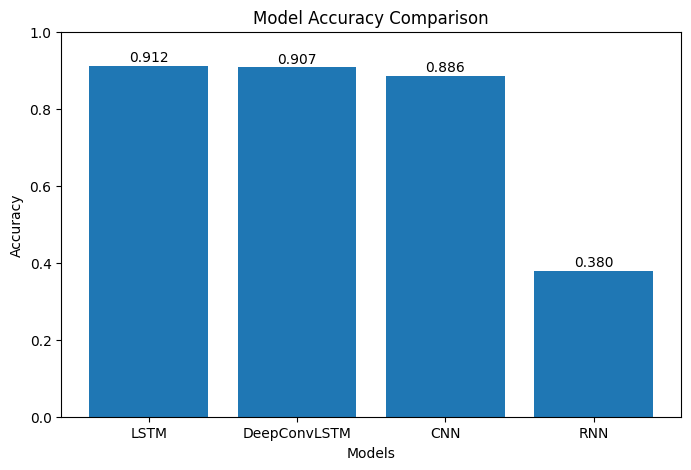

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.ylim(0,1)

for i, v in enumerate(results_df["Accuracy"]):
    plt.text(i, v+0.01, f"{v:.3f}", ha="center")

plt.show()

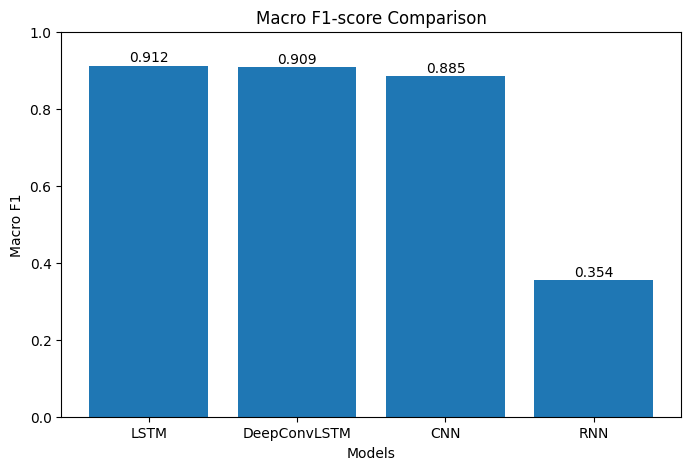

In [40]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["Macro F1"])

plt.title("Macro F1-score Comparison")
plt.xlabel("Models")
plt.ylabel("Macro F1")

plt.ylim(0,1)

for i, v in enumerate(results_df["Macro F1"]):
    plt.text(i, v+0.01, f"{v:.3f}", ha="center")

plt.show()

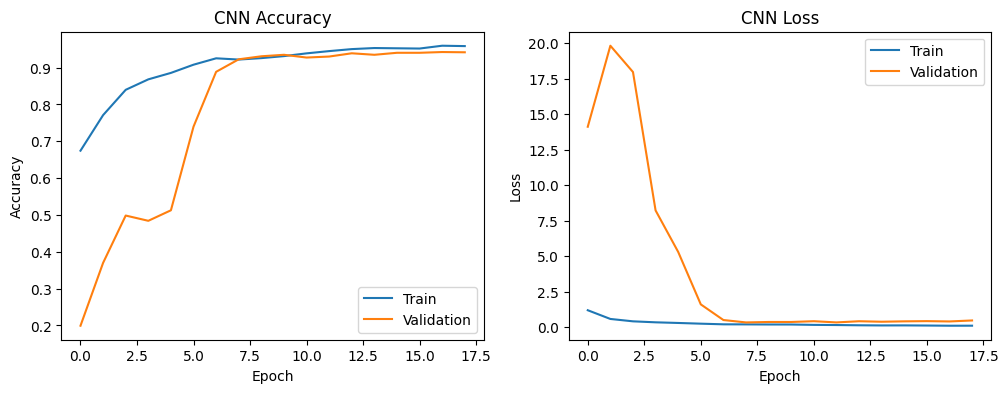

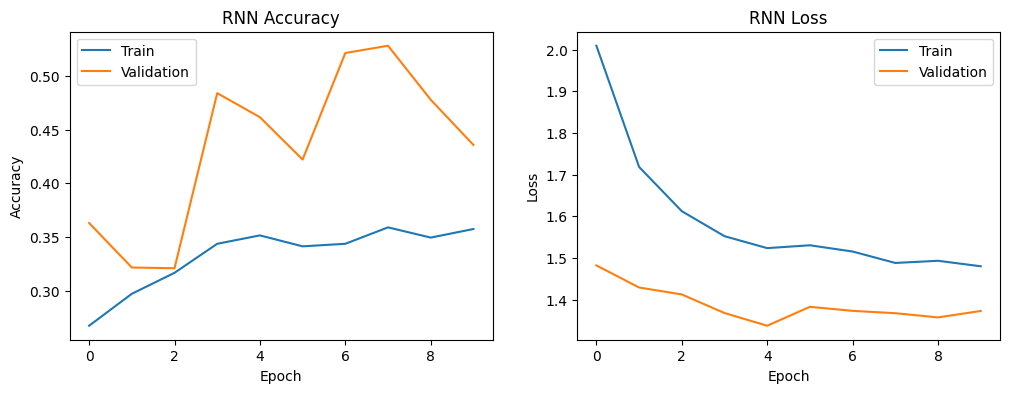

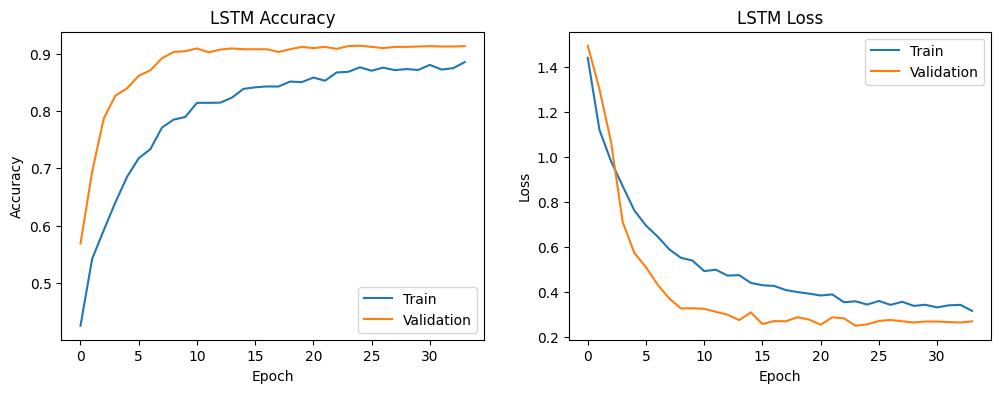

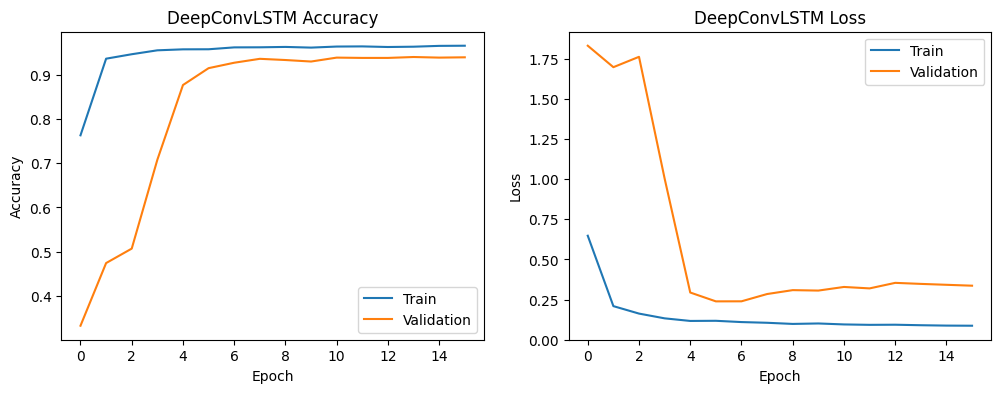

In [41]:
for model_name, history in histories.items():

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)

    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Validation")

    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1,2,2)

    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Validation")

    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

In [42]:
print("Best Model:", best_model_name)

Best Model: LSTM


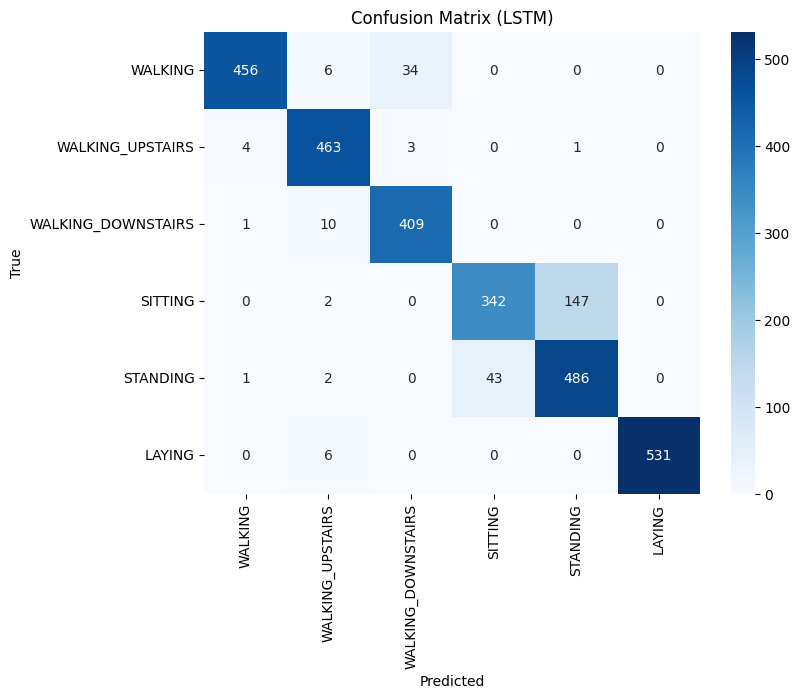

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABELS,
    yticklabels=LABELS
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix ({best_model_name})")

plt.show()

In [44]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    best_predictions,
    target_names=LABELS
))

                    precision    recall  f1-score   support

           WALKING       0.99      0.92      0.95       496
  WALKING_UPSTAIRS       0.95      0.98      0.96       471
WALKING_DOWNSTAIRS       0.92      0.97      0.94       420
           SITTING       0.89      0.70      0.78       491
          STANDING       0.77      0.91      0.83       532
            LAYING       1.00      0.99      0.99       537

          accuracy                           0.91      2947
         macro avg       0.92      0.91      0.91      2947
      weighted avg       0.92      0.91      0.91      2947

